In [1]:
import pandas as pd
import numpy as np
import statistics 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
from tqdm import tqdm

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

In [6]:
S=pd.read_csv("A.csv")
S.head(20)
Number=18
x=len(S["g_kvhh"])
B=np.zeros((x-1,Number))

100%|██████████| 2138/2138 [00:00<00:00, 7796.80it/s]


Text(0, 0.5, 'PC2')

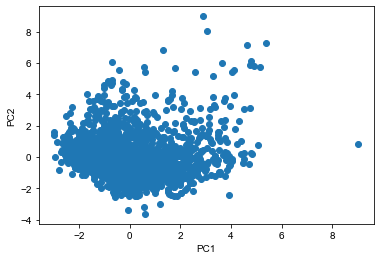

In [7]:
if(Number==18):
    b0=[]
    b1=[]
    b2=[]
    b3=[]
    b4=[]
    b5=[]
    b6=[]
    b7=[]
    b8=[]
    b9=[]
    b10=[]
    b11=[]
    b12=[]
    b13=[]
    b14=[]
    b15=[]
    b16=[]
    b17=[]

    for i in tqdm(range(x)):
        if(i==0):
            continue
        b0.append(S['g_leak'][i])
        b1.append(S['g_nav'][i])
        b2.append(S['g_kvhh'][i])
        b3.append(S['g_kva'][i])
        b4.append(S['g_kvsi'][i])
        b5.append(S['g_cav'][i])
        b6.append(S['g_kca'][i])
        b7.append(S['g_nap'][i])
        b8.append(S['g_kir'][i])
        b9.append(S['g_unav'][i])
        b10.append(S['g_kna'][i])
        b11.append(S['g_ampar'][i])
        b12.append(S['g_nmdar'][i])
        b13.append(S['g_gabar'][i])
        b14.append(S['t_ca'][i])
        b15.append(S['t_na'][i])
        b16.append(S['x_na'][i])
        b17.append(S['y_na'][i])


    for i in range(x-1):
        B[i][0]=(b0[i])/statistics.stdev(b0)
        B[i][1]=(b1[i])/statistics.stdev(b1)
        B[i][2]=(b2[i])/statistics.stdev(b2)
        B[i][3]=(b3[i])/statistics.stdev(b3)
        B[i][4]=(b4[i])/statistics.stdev(b4)
        B[i][5]=(b5[i])/statistics.stdev(b5)
        B[i][6]=(b6[i])/statistics.stdev(b6)
        B[i][7]=(b7[i])/statistics.stdev(b7)
        B[i][8]=(b8[i])/statistics.stdev(b8)
        B[i][9]=(b9[i])/statistics.stdev(b9)
        B[i][10]=(b10[i])/statistics.stdev(b10)
        B[i][11]=(b11[i])/statistics.stdev(b11)
        B[i][12]=(b12[i])/statistics.stdev(b12)
        B[i][13]=(b13[i])/statistics.stdev(b13)
        B[i][14]=(b14[i])/statistics.stdev(b14)
        B[i][15]=(b15[i])/statistics.stdev(b15)
        B[i][16]=(b16[i])/statistics.stdev(b16)
        B[i][17]=(b17[i])/statistics.stdev(b17)




#PCA analysis
pca.fit(B)
feature=pca.transform(B)
x=[]
y=[]
for i in range(len(feature)):
    x.append(feature[i][0])
    y.append(feature[i][1])

#plt.figure(figsize=(10,10))
plt.scatter(x,y)
plt.xlabel("PC1")
plt.ylabel("PC2")
#plt.savefig("Kernel.pdf")

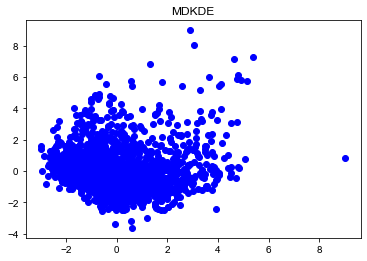

In [8]:
from scipy.stats import gaussian_kde
kde=gaussian_kde(feature.T)
x1=np.linspace(-5,8,500)
y1=np.linspace(-3,5,500)
xxx,yyy=np.meshgrid(x1,y1)
meshdata=np.vstack([xxx.ravel(), yyy.ravel()])

z=kde.evaluate(meshdata)


fig=plt.figure(facecolor="w")
ax=fig.add_subplot(111, title="MDKDE")
ax.scatter(feature[:,0], feature[:,1], c="b")

plt.show()

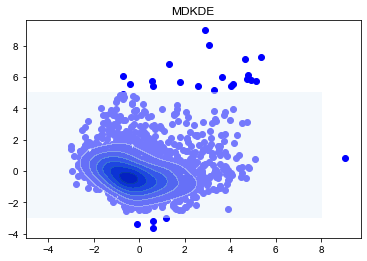

In [9]:
from scipy.stats import gaussian_kde
kde=gaussian_kde(feature.T)
x1=np.linspace(-5,8,500)
y1=np.linspace(-3,5,500)
xxx,yyy=np.meshgrid(x1,y1)
meshdata=np.vstack([xxx.ravel(), yyy.ravel()])

z=kde.evaluate(meshdata)


fig=plt.figure(facecolor="w")
ax=fig.add_subplot(111, title="MDKDE")
ax.scatter(feature[:,0], feature[:,1], c="b")
ax.contourf(xxx,yyy,z.reshape(len(x1),len(y1)), cmap="Blues", alpha=0.5)
plt.show()

In [10]:
cmax=max(z)
Z=z.reshape(500,500)
X=-100
Y=-100
A=-100
B=-100
Diff=1000000
for i in range(500):
    for j in range(500):
        dif=(cmax-Z[i][j])**2
        if(dif<=Diff):
            Diff=dif
            X=x1[i]
            Y=y1[j]
            A=i
            B=j


In [11]:
memo=-100
M=1000000
a=[]
psps1=[]

for i in range(len(feature)):
    m=(X-feature[i][0])**2+(Y-feature[i][1])**2
    psps1.append(m)
    if(m<=M):
        M=m
        memo=i
        a.append(memo)
    if(i==453):
        print(m)
print(memo)

0.560073823523074
1511


In [12]:
a

[0, 3, 15, 20, 1511]

In [13]:
FUMO=[]
for i in range(len(feature)):
    m=(X-feature[i][0])**2+(Y-feature[i][1])**2
    FUMO.append([m,i])

In [14]:
FUMO.sort()
print(FUMO[0])
print(FUMO[1])
print(FUMO[2])
print(FUMO[3])
print(FUMO[4])
print(FUMO[5])
print(FUMO[6])
print(FUMO[7])
print(FUMO[8])
print(FUMO[9])
print(FUMO[10])
print(FUMO[11])

[0.0005399920520508378, 1511]
[0.00057444258208876, 20]
[0.0008412158322171198, 1243]
[0.0014289579643383128, 76]
[0.0034398449528494682, 936]
[0.004274565386686604, 242]
[0.005729226356015768, 555]
[0.007242910245474963, 351]
[0.007595774444511907, 2030]
[0.007709118377167472, 1897]
[0.007963992598295588, 219]
[0.008781656456686665, 752]


In [23]:
A=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
BBB=['g_leak', 'g_nav', 'g_kvhh', 'g_kva', 'g_kvsi', 'g_cav', 'g_kca', 'g_nap', 'g_kir', 'g_unav', 'g_kna', 'g_ampar', 'g_nmdar', 't_ca', 't_na', 'x_na', 'y_na']
dic={key:  val for key, val in zip(BBB,A)}
new_params: pd.DataFrame=pd.DataFrame.from_dict(dic,orient='index').T
new_params.to_csv("B.csv")

In [24]:
for i in range(100):
    numb=FUMO[i][1]+1
    A=[]
    c=numb
    A.append(S['g_leak'][c])
    A.append(S['g_nav'][c])
    A.append(S['g_kvhh'][c])
    A.append(S['g_kva'][c])
    A.append(S['g_kvsi'][c])
    A.append(S['g_cav'][c])
    A.append(S['g_kca'][c])
    A.append(S['g_nap'][c])
    A.append(S['g_kir'][c])
    A.append(S['g_unav'][c])
    A.append(S['g_kna'][c])
    A.append(S['g_ampar'][c])
    A.append(S['g_nmdar'][c])
    A.append(S['t_ca'][c])
    A.append(S['t_na'][c])
    A.append(S['x_na'][c])
    A.append(S['y_na'][c])
        
    BBB=['g_leak', 'g_nav', 'g_kvhh', 'g_kva', 'g_kvsi', 'g_cav', 'g_kca', 'g_nap', 'g_kir', 'g_unav', 'g_kna', 'g_ampar', 'g_nmdar', 't_ca', 't_na', 'x_na', 'y_na']
    dic={key:  val for key, val in zip(BBB,A)}
        #new_params: pd.DataFrame=pd.DataFrame.from_dict(dic,orient='index').T
    new_params=dic
    T=pd.read_csv("B.csv")
    N: pd.DataFrame=pd.DataFrame.from_dict(new_params, orient="index").T
    T=pd.concat([T,N])
    print(len(T["g_kvhh"])-1)
    T.to_csv("B.csv")
        

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [25]:
tt=pd.read_csv("B.csv")
tt.head(3000)

,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,Unnamed: 0.1.1.1,Unnamed: 0.1.1.1.1,Unnamed: 0.1.1.1.1.1,Unnamed: 0.1.1.1.1.1.1,Unnamed: 0.1.1.1.1.1.1.1,Unnamed: 0.1.1.1.1.1.1.1.1,Unnamed: 0.1.1.1.1.1.1.1.1.1,...,g_nap,g_kir,g_unav,g_kna,g_ampar,g_nmdar,t_ca,t_na,x_na,y_na
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.311142,0.021680,2.353382,21.449636,2.728308,0.001290,106.710992,1687.377446,42.130722,-1.623032
2,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,0.722302,0.035461,15.462437,16.811553,0.124180,0.182623,394.462292,1056.622514,14.418942,5.161080
3,3,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,3.864087,0.011888,0.038280,2.005536,0.001405,2.432310,19.156423,3532.926155,44.951149,17.500896
4,4,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,0.804110,0.013872,0.223109,35.250582,2.541510,2.072003,19.599583,2849.022570,42.317317,22.952908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,96,96.0,96.0,96.0,0.0,NaN,NaN,NaN,NaN,NaN,...,0.686137,0.010949,2.626495,46.205775,0.010383,0.022159,11.685283,1286.910832,27.799649,6.813515
97,97,97.0,97.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,5.825287,0.025564,0.039054,6.258500,0.524328,0.001000,155.572975,1915.011125,38.226835,0.786350
98,98,98.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.753750,0.010905,5.763214,31.290292,0.185900,0.210910,128.356501,3058.942231,7.117776,41.316330
99,99,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.654698,0.014869,0.915592,3.683143,1.972097,0.014514,22.711101,2821.885732,42.097447,6.375154
